In [1]:
import sys
import numpy as np
import torch 
# still do preprocessing in scipy
import scipy.sparse as sp
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from importlib import reload
# get UMAP
import umap
from tqdm import tqdm
import pandas as pd

# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')
import factor_model
reload(factor_model)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='white', context='notebook', rc={'figure.figsize':(6,6)}, font_scale=1.5)

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB


In [2]:
# Append this directory to sys.path
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/')
import Leaflet_load_cluster_data_03 as llc 

# Append also simulation directory
sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/")
import Leaflet_simulate_counts as sim 
reload (sim)

<module 'Leaflet_simulate_counts' from '/gpfs/commons/home/kisaev/Leaflet-private/src/simulation/Leaflet_simulate_counts.py'>

### Settings

In [3]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

cuda


### Load junction and intron cluster counts

In [4]:
# let's simulate using the mammary gland data
input_files_folder = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/"
#cell_types = ["Mammary_Gland_basal_cell", "Mammary_Gland_luminal_epithelial_cell_of_mammary_gland"]

# convert data to Leaflet required input formats 
final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = llc.load_cluster_data(
    input_folder = input_files_folder, max_intron_count=5000, remove_singletons=True, has_genes="yes")  #, celltypes=cell_types)

# add cluster to final_data 
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index"], how="left")

# get indices (maybe don't need this actually)
indices = (final_data.cell_id_index, final_data.junction_id_index)
indices_np = np.stack(indices)
junc_counts = sp.coo_matrix((final_data.junc_count, indices))
cluster_counts = sp.coo_matrix((final_data.cluster_count, indices))

Reading in data from folder ...
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/model_input/Mammary_Gland/
Finished reading in data from folder ...
Removing singletons ...
Number of junctions before removing singletons:  157665
Number of junctions after removing singletons:  47015
The number of unique cell types in the data is:  4
The number of unique cells in the data is:  2405
The number of unique junctions in the data is:  47016
The maximum junction count was initially:  251545
375
The maximum junction count is now:  4999
The number of junctions in the data is:  44087
The number of cells in the data is:  2405
The number of cell types in the data is:  4


In [5]:
# double check which cell types are present
cell_ids_conversion.cell_type.value_counts()

Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: cell_type, dtype: int64

In [6]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])
print(cluster_counts.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].junction_id_index])

cell_id_index                                                  1856
junction_id_index                                               833
junc_count                                                     10.0
cluster_count                                                    28
clustminjunc                                                   18.0
juncratio                                                  0.357143
cell_id              M2-B002436-3_39_F-1-1_Mammary_Gland_basal_cell
cell_type                                  Mammary_Gland_basal_cell
junction_id                                   2_174465936_174466725
Cluster                                                       16496
gene_id                                                       Slmo2
Name: 10441144, dtype: object
10.0
28


### For simulating data, let's only keep clusters that have exon skipping event, so cluster with three junctions 

In [7]:
# SS are shared between end of J1 and start of J2 and end of J2 and start of J3
junc_info = junction_ids_conversion[["junction_id", "Cluster", "junction_id_index"]].drop_duplicates()

# get number of junctions in each cluster first 
cluster_junc_counts = junc_info.groupby(["Cluster"]).agg({"junction_id": "count"}).reset_index()
clusts_keep = cluster_junc_counts[cluster_junc_counts["junction_id"] == 3 ]
junc_info = junc_info[junc_info["Cluster"].isin(clusts_keep["Cluster"])]

# break up junction_id column in junc_info into chr, start and end 
junc_info["chr"] = junc_info["junction_id"].str.split("_").str[0]
junc_info["start"] = junc_info["junction_id"].str.split("_").str[1]
junc_info["end"] = junc_info["junction_id"].str.split("_").str[2]
print(len(junc_info["Cluster"].unique()))

6594


In [8]:
# run function on all clusters to find simple exon skipping events 
clusters_SS = []

for cluster in tqdm(junc_info["Cluster"].unique()): # this is very slow
    clusters_SS.append(sim.check_SS_cluster(final_data, junc_info, cluster))

# keep only entries in clusters_SS that are not None 
clusters_SS = [x for x in clusters_SS if x is not None]
print(len(clusters_SS))

# get indices of junctions in clusters_SS (original indices before filtering)
junc_ind_keep = junction_ids_conversion[junction_ids_conversion["Cluster"].isin(clusters_SS)]["junction_id_index"]
print(len(junc_ind_keep))
final_data = final_data[final_data.junction_id_index.isin(junc_ind_keep)] #using original junction id index

# filter junction_ids file to only include junctions in clusters_SS
junction_ids_conversion = junction_ids_conversion[junction_ids_conversion["junction_id_index"].isin(junc_ind_keep)]
# reset index of junction_ids_conversion and make a new column new_junction_id_index
junction_ids_conversion = junction_ids_conversion.reset_index(drop=True)
# re-order junction_ids_conversion junction_id_index
junction_ids_conversion = junction_ids_conversion.sort_values(by=['junction_id_index'])
junction_ids_conversion["new_junction_id_index"] = junction_ids_conversion.index
print(junction_ids_conversion.head())

# re-order the remaining junctions and subset the counts matrices
final_data = final_data.merge(junction_ids_conversion, on=["junction_id_index", "Cluster", "junction_id"])

# where is new_junction_id_index coming from here? 
final_data.sort_values(by = ["new_junction_id_index"], inplace = True)
final_data.head()

to_keep = final_data["junction_id_index"].unique()   # use original junction indices to filter out the count matrices 
junc_counts_sub = junc_counts.tocsr()[:,to_keep].tocoo()
cluster_counts_sub = cluster_counts.tocsr()[:,to_keep].tocoo()

100%|██████████| 6594/6594 [07:03<00:00, 15.59it/s]


6388
19164
   junction_id_index          junction_id  Cluster gene_id  \
0                 12  1_78692220_78694195      114   Acsl3   
1                 13  1_78694346_78696080      114   Acsl3   
2                 20  1_74236899_74246079      344   Arpc2   
3                 21  1_74246114_74248131      344   Arpc2   
4                 22  1_74255014_74255957      347   Arpc2   

   new_junction_id_index  
0                      0  
1                      1  
2                      2  
3                      3  
4                      4  


In [9]:
# sanity check that counts are saved in correct indices in sparse matrices
ind_random = np.random.randint(0, len(final_data))
print(final_data.iloc[ind_random])
print(junc_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])
print(cluster_counts_sub.toarray()[final_data.iloc[ind_random].cell_id_index, final_data.iloc[ind_random].new_junction_id_index])

cell_id_index                                                         2277
junction_id_index                                                    22095
junc_count                                                             0.0
cluster_count                                                           71
clustminjunc                                                          71.0
juncratio                                                              0.0
cell_id                  P12-B002432-3_38_F-1-1_Mammary_Gland_luminal_e...
cell_type                Mammary_Gland_luminal_epithelial_cell_of_mamma...
junction_id                                            8_95422894_95434487
Cluster                                                              57562
gene_id_x                                                             Gtl3
gene_id_y                                                             Gtl3
new_junction_id_index                                                 9912
Name: 6438006, dtype: obj

<Axes: xlabel='juncratio', ylabel='Count'>

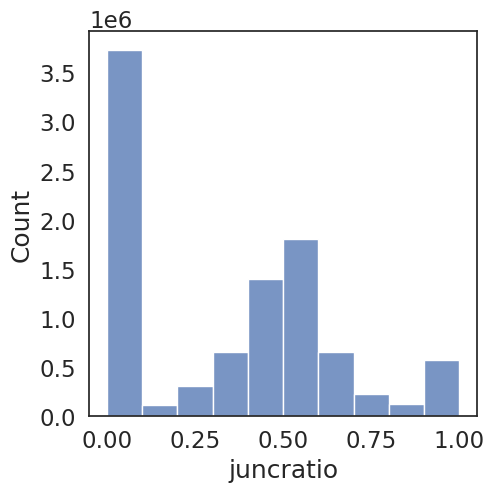

In [10]:
# set figure size to be small
plt.figure(figsize=(5,5))
sns.histplot(final_data.juncratio, bins=10)

### Let's simulate some data!

In [11]:
# update junc_info to only include junctions in clusters_SS
junc_info = junc_info[junc_info["Cluster"].isin(clusters_SS)]
junc_info = junc_info.reset_index(drop=True)
junc_info["new_junction_id_index"] = junc_info.index
junc_info.head()

,junction_id,Cluster,junction_id_index,chr,start,end,new_junction_id_index
0,1_78692220_78694195,114,12,1,78692220,78694195,0
1,1_78694346_78696080,114,13,1,78694346,78696080,1
2,1_74236899_74246079,344,20,1,74236899,74246079,2
3,1_74246114_74248131,344,21,1,74246114,74248131,3
4,1_74255014_74255957,347,22,1,74255014,74255957,4


In [12]:
cell_ids_conversion.cell_type.value_counts()

Mammary_Gland_basal_cell                                  1340
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     578
Mammary_Gland_stromal_cell                                 440
Mammary_Gland_endothelial_cell                              47
Name: cell_type, dtype: int64

In [13]:
simulated_counts, cell_types, cell_type_psi, cluster_labels = sim.simulate_junc_counts(cluster_counts_sub, junc_info, cell_types=cell_ids_conversion.cell_type.astype('category'))

Using pre-defined cell types!
The number of cell types is: 4
The number of cells is: 2405
The number of junctions is: 19164


100%|██████████| 6388/6388 [00:18<00:00, 342.98it/s]


The columns to keep are: Index([0, 1, 2, 3], dtype='object')
Done simulating PSI!
Done simulating junc counts!


In [14]:
# save simulated counts, cell types and psi values
sim_juncs_counts = simulated_counts
cell_type_psi_df = cluster_labels

# get variance in simulated psi values across all simulated cell types 
K = len(cell_types)
cell_type_psi_df["difference"] = np.mean(cell_type_psi_df[0:K])
cell_type_psi_df.head()

/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/gpfs/commons/home/kisaev/miniconda3/envs/leafcutter-sc/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3430: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


,0,1,2,3,new_junction_id_index,sample_label,Cluster,difference
0,0.081535,0.155184,0.049865,0.265594,0,positive,114,0.257774
2,0.081535,0.155184,0.049865,0.265594,1,positive,114,0.257674
0,0.474011,0.474011,0.474011,0.474011,2,negative,344,0.257774
2,0.474011,0.474011,0.474011,0.474011,3,negative,344,0.257674
0,0.055675,0.106546,0.355142,0.384466,4,positive,347,0.257774


In [15]:
# label anything with absolute difference of 0.2 or less as not cell state associated 
cell_type_psi_df["true_label"] = np.where(abs(cell_type_psi_df["difference"]) >= 0.2, "positive", "negative")
cell_type_psi_df.sort_values(by = ["new_junction_id_index"], inplace = True)
cell_type_psi_df.true_label.value_counts()

positive    19164
Name: true_label, dtype: int64

In [16]:
# make dataframe using the following columsn 
sim_junc_counts_flat = pd.DataFrame({"cell_id_index": sim_juncs_counts.row, "new_junction_id_index": sim_juncs_counts.col, "new_junc_count": sim_juncs_counts.data})
sim_junc_counts_flat.head()

# also add new cell type column 
sim_junc_counts_flat["new_cell_type"] = np.array(cell_types[sim_junc_counts_flat["cell_id_index"]])
sim_junc_counts_flat.head()

,cell_id_index,new_junction_id_index,new_junc_count,new_cell_type
0,0,0,0.0,0
1,0,1,3.0,0
2,0,2,11.0,0
3,0,3,7.0,0
4,0,4,2.0,0


In [17]:
# update junction counts in final_data object to be the simulated counts 
final_data = final_data.merge(sim_junc_counts_flat, on = ["cell_id_index", "new_junction_id_index"])
final_data.head()

,cell_id_index,junction_id_index,junc_count,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id_x,gene_id_y,new_junction_id_index,new_junc_count,new_cell_type
0,0,12,19.0,24,5.0,0.791667,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,0.0,0
1,1713,12,1.0,2,1.0,0.500000,L21-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,0.0,0
2,1718,12,3.0,5,2.0,0.600000,L22-B002309-3_57_F-1-1_Mammary_Gland_stromal_cell,Mammary_Gland_stromal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,1.0,3
3,1721,12,12.0,21,9.0,0.571429,L22-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,1.0,0
4,1722,12,36.0,52,16.0,0.692308,L22-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,6.0,0


In [18]:
sim_data = final_data.copy() 
# drop the old junction counts and junction id index
sim_data.drop(columns = ["junc_count", "junction_id_index"], inplace = True)
# rename columns new_junction_id_index and new_junc_count to junction_id_index and junc_count
sim_data.rename(columns = {"new_junction_id_index": "junction_id_index", "new_junc_count": "junc_count"}, inplace = True)
sim_data.head()

,cell_id_index,cluster_count,clustminjunc,juncratio,cell_id,cell_type,junction_id,Cluster,gene_id_x,gene_id_y,junction_id_index,junc_count,new_cell_type
0,0,24,5.0,0.791667,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,0.0,0
1,1713,2,1.0,0.500000,L21-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,0.0,0
2,1718,5,2.0,0.600000,L22-B002309-3_57_F-1-1_Mammary_Gland_stromal_cell,Mammary_Gland_stromal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,1.0,3
3,1721,21,9.0,0.571429,L22-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,1.0,0
4,1722,52,16.0,0.692308,L22-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,Mammary_Gland_basal_cell,1_78692220_78694195,114,Acsl3,Acsl3,0,6.0,0


In [19]:
# update cluster_count to be the sum of junction_id_index in each Cluster for each cell
new_clust_counts = sim_data.groupby(["cell_id_index", "Cluster"]).agg({"junc_count": "sum"}).reset_index()
# update column to be cluster_count 
new_clust_counts.rename(columns = {"junc_count": "cluster_count"}, inplace = True)
sim_data.drop(columns = ["cluster_count"], inplace = True)
# merge new_clust_counts with sim_data
sim_data = sim_data.merge(new_clust_counts, on = ["cell_id_index", "Cluster"])

<Axes: xlabel='junc_ratio', ylabel='Count'>

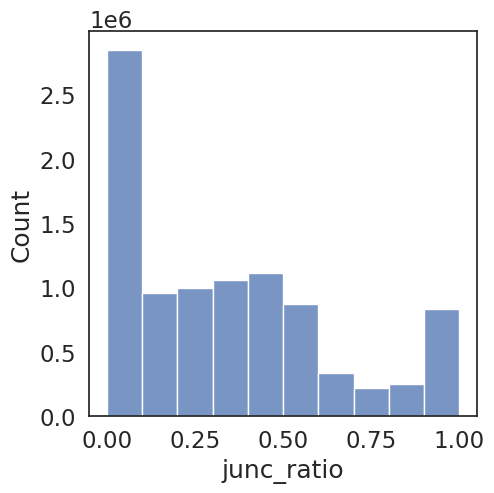

In [20]:
# update juncratio 
sim_data["clustminjunc"] = sim_data["cluster_count"] - sim_data["junc_count"]
sim_data["junc_ratio"] = sim_data["junc_count"] / sim_data["cluster_count"]

# make histogram of junc_ratio
plt.figure(figsize=(5,5))
sns.histplot(sim_data.junc_ratio, bins=10)

### Prep data for model 

In [21]:
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

In [22]:
cell_index_tensor, junc_index_tensor, my_data = llc.make_torch_data(sim_data, **float_type)

The number of cells going into training data is:
2405
2405


/gpfs/commons/home/kisaev/Leaflet-private/src/clustering/Leaflet_load_cluster_data_03.py:45: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at ../aten/src/ATen/SparseCsrTensorImpl.cpp:53.)
  ycount_lookup = torch.sparse_coo_tensor(


In [23]:
clust_labels_only = cluster_labels[["Cluster", "sample_label"]].drop_duplicates()
simple_data = sim_data[["cell_id_index", "Cluster", "cell_type", "junction_id_index", "junc_ratio", "junc_count", "cluster_count"]]
# merge with clust_labels_only 
simple_data = simple_data.merge(clust_labels_only, on = ["Cluster"])
# get true PSI for each Cluster 
simple_data.head()

,cell_id_index,Cluster,cell_type,junction_id_index,junc_ratio,junc_count,cluster_count,sample_label
0,0,114,Mammary_Gland_basal_cell,0,0.00,0.0,25.0,positive
1,0,114,Mammary_Gland_basal_cell,1,0.12,3.0,25.0,positive
2,0,114,Mammary_Gland_basal_cell,16117,0.88,22.0,25.0,positive
3,1713,114,Mammary_Gland_basal_cell,0,0.00,0.0,2.0,positive
4,1713,114,Mammary_Gland_basal_cell,1,0.00,0.0,2.0,positive


99943
Mammary_Gland_basal_cell                                  1623
Mammary_Gland_luminal_epithelial_cell_of_mammary_gland     684
Mammary_Gland_stromal_cell                                 126
Mammary_Gland_endothelial_cell                               6
Name: cell_type, dtype: int64


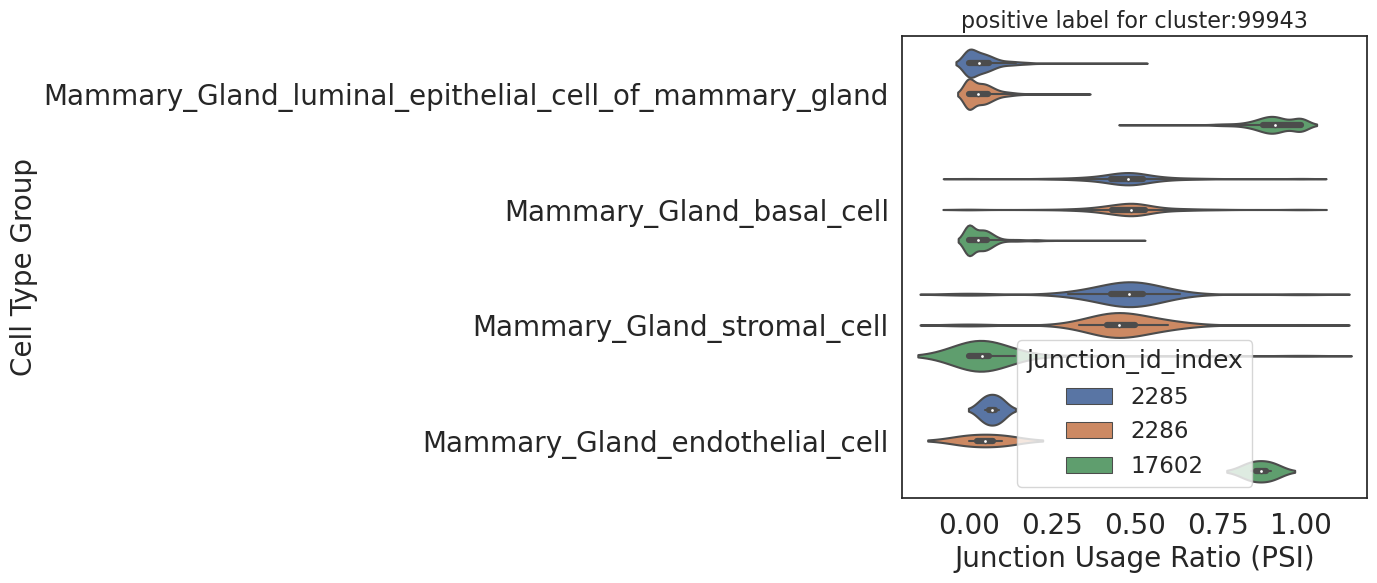

In [24]:
# let's visualize junction usage ratios for a given custer 
# sample clust from simple_data.Cluster.unique()
clust = np.random.choice(simple_data.Cluster.unique())
print(clust)
sim.quick_clust_plot(clust, simple_data)

In [25]:
indices = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values = torch.tensor(sim_data['junc_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells = sim_data['cell_id_index'].max() + 1
num_junctions = sim_data['junction_id_index'].max() + 1
size = (num_cells, num_junctions)
# Create a sparse tensor
y_tensor = torch.sparse_coo_tensor(indices, values, size)

In [26]:
indices_counts = torch.tensor(sim_data[['cell_id_index', 'junction_id_index']].to_numpy().T, dtype=torch.long)
values_counts = torch.tensor(sim_data['cluster_count'].to_numpy(), dtype=torch.float)
# Determine the size of the tensor
num_cells_counts = sim_data['cell_id_index'].max() + 1
num_junctions_counts = sim_data['junction_id_index'].max() + 1
size_counts = (num_cells_counts, num_junctions_counts)
# Create a sparse tensor
total_counts_tensor = torch.sparse_coo_tensor(indices_counts, values_counts, size_counts)

In [27]:
# save full dataset y_tensor and total_counts_tensor 
full_y_tensor = y_tensor
full_total_counts_tensor = total_counts_tensor

In [28]:
# remake junction counts and cluster counts sp.coo_matrix for masking analysis
indices = (sim_data.cell_id_index, sim_data.junction_id_index)
junc_counts = sp.coo_matrix((sim_data.junc_count, indices))
cluster_counts = sp.coo_matrix((sim_data.cluster_count, indices))

### Evaluate model performance when masking some of the input data

In [29]:
# import factor model from beta-dirichlet-factor
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations')
import masking
from masking import *

# import reload 
from importlib import reload
reload(masking)

<module 'masking' from '/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py'>

In [30]:
#1. get masked matrix using intron cluster counts for this mouse brain data 

# same masking percentage for all three matrices but generating three different masks
masking_percs = [0.05, 0.1, 0.1001, 0.2]
masks_list = []
seeds_used = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting masked matrix for each masking percentage")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for perc_mask in masking_percs:
    print("The masking percentage is: " + str(perc_mask))
    masked_matrix, seed = generate_mask(cluster_counts, mask_percentage = perc_mask, randomize_seed = True)
    seeds_used.append(seed)
    # append to masks_list
    masks_list.append(masked_matrix)

#2. get junction and intron cluster count matrices with masked values 
masked_counts = []

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting junction and intron cluster count matrices with masked values")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = apply_mask(junc_counts, cluster_counts, masks_list[i])
    # appent masked junction and intron cluster counts to list
    masked_counts.append((masked_junction_counts, masked_intron_clusts))

#3. get input files for factor model (junction and intron cluster sparse tensor)
model_input_files = [] 

print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
print("Getting input files for factor model")
print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")

for i in range(len(masking_percs)):
    print("The masking percentage is: " + str(masking_percs[i]))
    masked_junction_counts, masked_intron_clusts = masked_counts[i]
    # get y_tensor and total_counts_tensor via prep_model_input function
    y_tensor, total_counts_tensor = prep_model_input(masked_junction_counts, masked_intron_clusts)
    # append to model_input_files list
    model_input_files.append((y_tensor, total_counts_tensor))

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Getting masked matrix for each masking percentage
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The masking percentage is: 0.05
The seed is:  810362
[5658464 3202842 2182271 1141627 9031384  237369  201810  131385 2463347
 6858007 1650871 6961782  288072 4821405 3701477 4569163 1484769 6974982
 3844296 4682560 8666650 4147239 5932624 4204198 3605123 6836847 3296887
 8649658 8233095 7004536 1873612 5033730  156669 3570252 1219668 6040273
 1100524 2146837 5143806 4011269 8293972  161568 1359187 1027092 1120967
 8187564 1698677 2151710 4849780 7820563]
Number of entries (junction-cell pairs) masked:  479715.0
The masking percentage is: 0.1
The seed is:  306774
[7644468 8901918 6998635 2056398 8404528 8365860 6040321 1691437  219524
 3085670 5586460 3723025 4334599 3688252 6785725  776359 7399523 9416476
 7229939  673095 6078567 8740169 8461030 9407658  237101 4744472 3994514
  865112 8663211 1222

/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:139: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:245.)
  indices = torch.tensor(np.nonzero(masked_intron_clusts), dtype=torch.long)


The masking percentage is: 0.1
The masking percentage is: 0.1001
The masking percentage is: 0.2


In [34]:
# Now can run factor model on masked data
Ks = [5, 20, 100, 500]
all_Ks_results = {}
# Seeds used for masking 
seeds_used 

# define list of seeds for training factor model 
seeds = [42, 52, 102]

# set concentration value to infinity 
init_conc = float('inf')

print("Learning rate seems to matter especially when K > 100, consider reducing it if running into NaN issues!")

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        print("The masking percentage is: " + str(masking_percs[i]))
        print("++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=True, input_conc=init_conc, K=k, seeds=seeds,loss_plot=False, num_epochs=500, lr = 0.01, save_to_file = False)
        # save results to dictionary
        all_Ks_results[(k, masking_percs[i])] = masked_results

------------------------------------------------
Running factor model for K = 5
------------------------------------------------
The masking percentage is: 0.05
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a fixed probability of success across all trials (infinite concentration parameter) with a binomial distribution.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 42
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 184239103.55676115
Epoch 20, Elbo loss: 159251765.04541534
Epoch 40, Elbo loss: 138384247.63876942
Epoch 60, Elbo loss: 121141627.42267035
Epoch 80, Elbo loss: 106824245.59016371
Epoch 100, Elbo loss: 94300354.63275999
Epoch 120, Elbo loss: 83325563.8644557
Epoch 14

Elbo loss: 19888886.911067355


Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 52
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 184383612.95744744
Epoch 20, Elbo loss: 159698325.37310517
Epoch 40, Elbo loss: 138858062.98970595
Epoch 60, Elbo loss: 121944126.60051964
Epoch 80, Elbo loss: 107637337.57345085
Epoch 100, Elbo loss: 95203515.70993388
Epoch 120, Elbo loss: 84412640.88405822
Epoch 140, Elbo loss: 74567847.64372931
Epoch 160, Elbo loss: 65634916.8115808
Epoch 180, Elbo loss: 57912783.7997067
Epoch 200, Elbo loss: 51618099.35602753
Epoch 220, Elbo loss: 46230262.33864045
Epoch 240, Elbo loss: 41938195.372438155
Epoch 260, Elbo loss: 38332283.851887584
Epoch 280, Elbo loss: 35283933.35817491
Epoch 300, Elbo loss: 32656929.879681572
Epoch 320, Elbo loss: 30460490.74128414
Epoch 340, Elbo loss: 28451981.58044976
Epoch 360, Elbo loss: 26785145.7804995

Elbo loss: 20005510.943170853


Sample from the guide (posterior)
Extract the latent variables
Initialization 3 with seed 102
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 179581128.41892582
Epoch 20, Elbo loss: 155143737.57369536
Epoch 40, Elbo loss: 134836532.69556326
Epoch 60, Elbo loss: 118197520.5222596
Epoch 80, Elbo loss: 104389011.19909462
Epoch 100, Elbo loss: 92879672.04689851
Epoch 120, Elbo loss: 82793972.10232346
Epoch 140, Elbo loss: 73884655.08719225
Epoch 160, Elbo loss: 65645745.95529107
Epoch 180, Elbo loss: 58152330.24526261
Epoch 200, Elbo loss: 51480882.223352954
Epoch 220, Elbo loss: 45536227.82482386
Epoch 240, Elbo loss: 40402481.04743786
Epoch 260, Elbo loss: 35990033.84902103
Epoch 280, Elbo loss: 32405886.698153004
Epoch 300, Elbo loss: 29621045.36897617
Epoch 320, Elbo loss: 27363102.443122875
Epoch 340, Elbo loss: 25494177.6643411
Epoch 360, Elbo loss: 24065924.992903

...

Sample from the guide (posterior)
Extract the latent variables
Initialization 2 with seed 52
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 184296786.24757928
Epoch 20, Elbo loss: 160535191.9604469
Epoch 40, Elbo loss: 140727262.92814574
Epoch 60, Elbo loss: 123516683.4868263
Epoch 80, Elbo loss: 108439433.89226088
Epoch 100, Elbo loss: 93939117.76547731
Epoch 120, Elbo loss: 80555867.79710168
Epoch 140, Elbo loss: 68174080.18381637
Epoch 160, Elbo loss: 57249671.055468455
Epoch 180, Elbo loss: 47910139.26120858
Epoch 200, Elbo loss: 40293441.8727929
Epoch 220, Elbo loss: 34445002.35296874
Epoch 240, Elbo loss: 30170635.155834638
Epoch 260, Elbo loss: 26798583.541595466
Epoch 280, Elbo loss: 24474456.065432213
Epoch 300, Elbo loss: 22657828.24246753
Epoch 320, Elbo loss: 21377117.86130307
Epoch 340, Elbo loss: 20333118.022305038
Epoch 360, Elbo loss: 19478025.079006

Elbo loss: 16887093.702473067


Sample from the guide (posterior)
Extract the latent variables
Initialization 3 with seed 102
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 179302075.72537488
Epoch 20, Elbo loss: 156423950.72290614
Epoch 40, Elbo loss: 137108932.35325468
Epoch 60, Elbo loss: 120704137.04301915
Epoch 80, Elbo loss: 105498594.99500048
Epoch 100, Elbo loss: 91845931.34555519
Epoch 120, Elbo loss: 78710617.78419134
Epoch 140, Elbo loss: 66679305.17528387
Epoch 160, Elbo loss: 55957827.64432732
Epoch 180, Elbo loss: 47108091.82296453
Epoch 200, Elbo loss: 40074693.55995938
Epoch 220, Elbo loss: 34305273.02839801
Epoch 240, Elbo loss: 30080836.644679822
Epoch 260, Elbo loss: 27116732.52164808
Epoch 280, Elbo loss: 24639679.17498031
Epoch 300, Elbo loss: 23022837.587035783
Epoch 320, Elbo loss: 21738837.681479044
Epoch 340, Elbo loss: 20646348.055677183
Epoch 360, Elbo loss: 19714689.949

Elbo loss: 16850935.742692947


Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [ ]:
print("---------------------------------------------")
print("Double check why getting this --> /gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:187: RuntimeWarning: invalid value encountered in divide")
print("---------------------------------------------")

In [35]:
# Get pearson correlation and l1 error between true and inferred parameters (PSI)
masked_perf = []

for k in Ks:
    for perc_mask in masking_percs:
        print("Calculating performance for K = " + str(k) + " and masking percentage = " + str(perc_mask))
        masked_results = all_Ks_results[(k, perc_mask)]        
        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2, rmse = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, rmse, K, perc_mask, J, nepoch])

Calculating performance for K = 5 and masking percentage = 0.05


/gpfs/commons/home/kisaev/Leaflet-private/src/evaluations/masking.py:187: RuntimeWarning: invalid value encountered in divide
  true_psi = true_juncs / true_clusts


L1 error:  0.0759394
Spearman correlation:  0.8905601535421817
L2 error:  0.014672916
RMSE:  0.121131815
L1 error:  0.07631764
Spearman correlation:  0.8901623304295437
L2 error:  0.014750783
RMSE:  0.1214528
L1 error:  0.0742901
Spearman correlation:  0.8929110934012852
L2 error:  0.014333455
RMSE:  0.11972241
Calculating performance for K = 5 and masking percentage = 0.1
L1 error:  0.07609303
Spearman correlation:  0.8902353764174941
L2 error:  0.0147185875
RMSE:  0.12132019
L1 error:  0.07617623
Spearman correlation:  0.8904394629241957
L2 error:  0.014714153
RMSE:  0.121301904
L1 error:  0.07410107
Spearman correlation:  0.8931990067159894
L2 error:  0.014295241
RMSE:  0.11956271
Calculating performance for K = 5 and masking percentage = 0.1001
L1 error:  0.076093204
Spearman correlation:  0.8902428729680544
L2 error:  0.014719453
RMSE:  0.12132375
L1 error:  0.07627281
Spearman correlation:  0.8902346001091563
L2 error:  0.014742028
RMSE:  0.121416755
L1 error:  0.07414482
Spearma

In [36]:
import pandas as pd 
# make masked_perf a dataframe 
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "rmse", "K",  "perc_masked" , "J", "num_epochs"])
# get current date and time to add to file name for saving 
from datetime import datetime
now = datetime.now()
file_name = "simulated_masked_perf_df_" + now.strftime("%Y%m%d_%H%M%S")
# save to compressed csv
masked_perf_df.to_csv(file_name, compression='gzip')

### Summarize masking analysis with plots

In [37]:
masked_perf_df.head()

,seed,l1,r,l2,rmse,K,perc_masked,J,num_epochs
0,42,0.075939,0.890560,0.014673,0.121132,5,0.05,19164,500
1,52,0.076318,0.890162,0.014751,0.121453,5,0.05,19164,500
2,102,0.074290,0.892911,0.014333,0.119722,5,0.05,19164,500
3,42,0.076093,0.890235,0.014719,0.121320,5,0.10,19164,500
4,52,0.076176,0.890439,0.014714,0.121302,5,0.10,19164,500


In [38]:
# make new column combining seed and perc_masked
masked_perf_df['seed_perc_masked'] = masked_perf_df['seed'].astype(str) + "_" + masked_perf_df['perc_masked'].astype(str)
masked_perf_df.head()

# there should be 2 seperate seed_perc_masked values for each K because there were two seperate masks used 
masked_perf_df['seed_perc_masked'].value_counts()

42_0.05       4
52_0.05       4
102_0.05      4
42_0.1        4
52_0.1        4
102_0.1       4
42_0.1001     4
52_0.1001     4
102_0.1001    4
42_0.2        4
52_0.2        4
102_0.2       4
Name: seed_perc_masked, dtype: int64

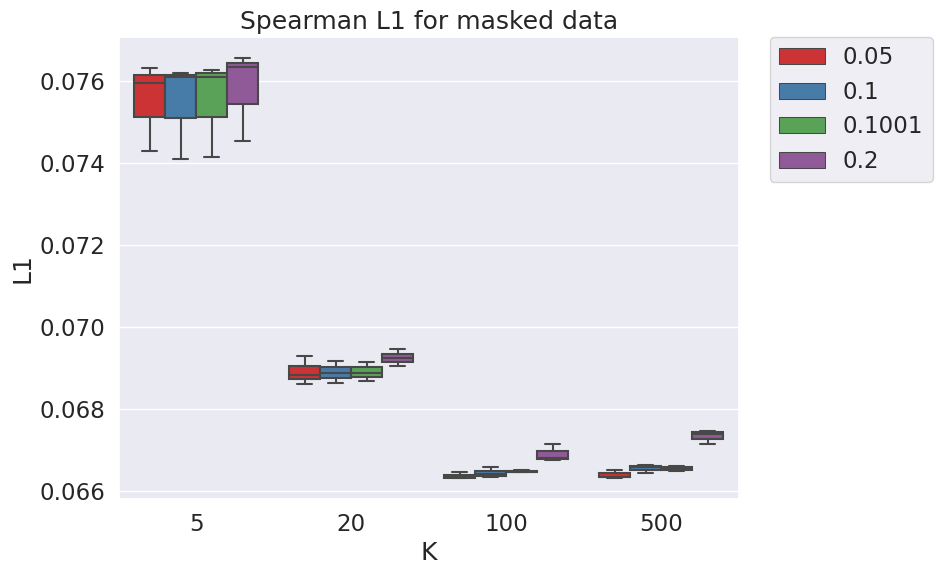

0.0663057


In [39]:
# make boxplot of l1 error for each K and masking percentage
# sns.set_style("whitegrid")
import seaborn as sns
import matplotlib.pyplot as plt 

# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="l1", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("L1")
ax.set_title("Spearman L1 for masked data")

# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()

print(masked_perf_df.l1.min())

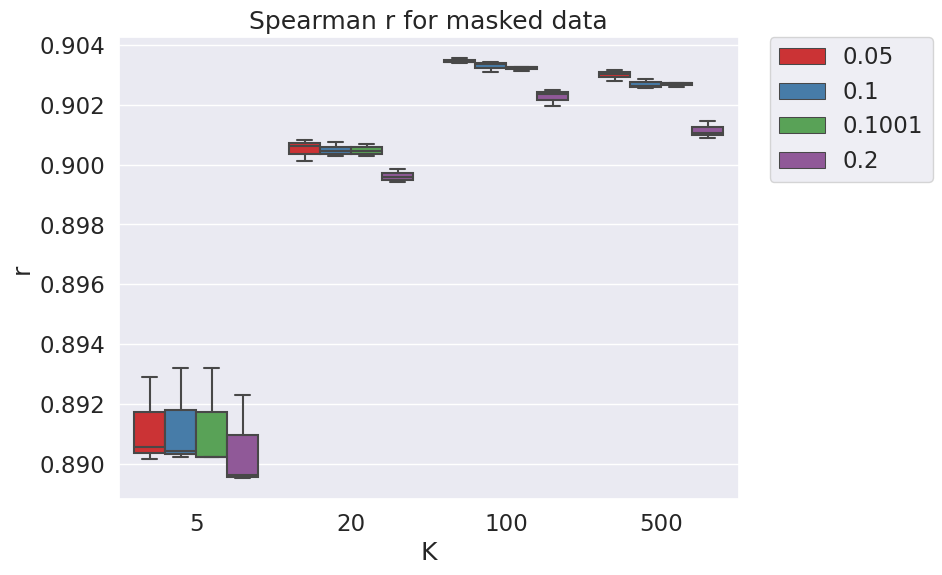

0.9035527327241394


In [40]:
# make boxplot for r 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="r", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("r")
ax.set_title("Spearman r for masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.r.max())

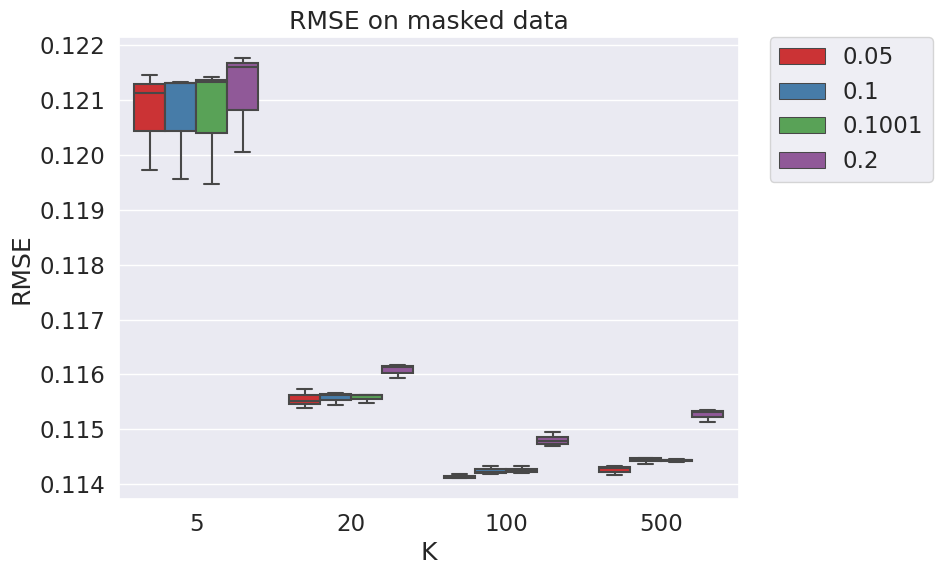

0.114106715


In [41]:
# make boxplot for rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))

ax = sns.boxplot(x="K", y="rmse", data=masked_perf_df, palette="Set1", hue="perc_masked")
ax.set_xlabel("K")
ax.set_ylabel("RMSE")
ax.set_title("RMSE on masked data")
# put legend on the outside 
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.show()
print(masked_perf_df.rmse.min())

K = 5
K = 20
K = 100


/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/seaborn/categorical.py:1781: UserWarning: You passed a edgecolor/edgecolors ((0.21568627450980393, 0.49411764705882355, 0.7215686274509804)) for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/seaborn/categorical.py:1781: UserWarning: You passed a edgecolor/edgecolors ((0.21568627450980393, 0.49411764705882355, 0.7215686274509804)) for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,
/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/seaborn/categorical.py:1781: UserWarning: You passed a edgecolor/edgecolors ((0.21568627450980393, 0.49411764705882355, 0.7215686274509804)) for an unfilled marker ('x').  Matplotlib is ignor

K = 500


/gpfs/commons/home/kisaev/.local/lib/python3.9/site-packages/seaborn/categorical.py:1781: UserWarning: You passed a edgecolor/edgecolors ((0.21568627450980393, 0.49411764705882355, 0.7215686274509804)) for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, y, label=hue_level,


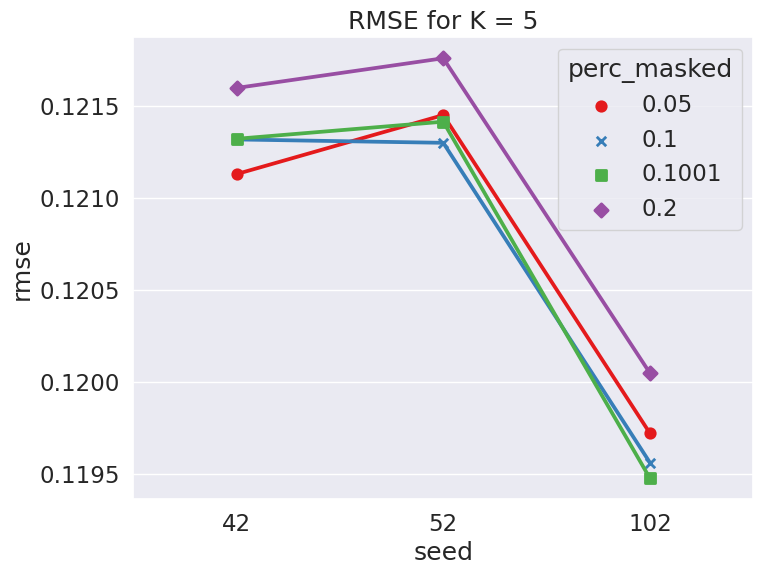

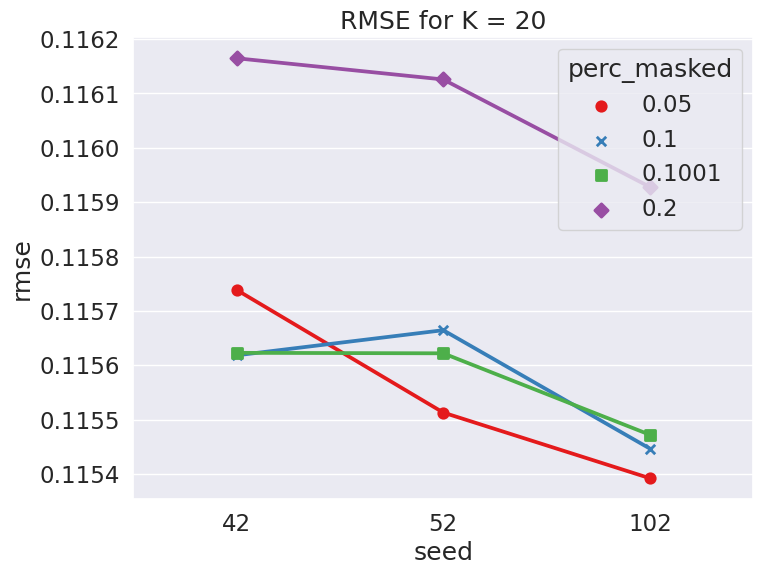

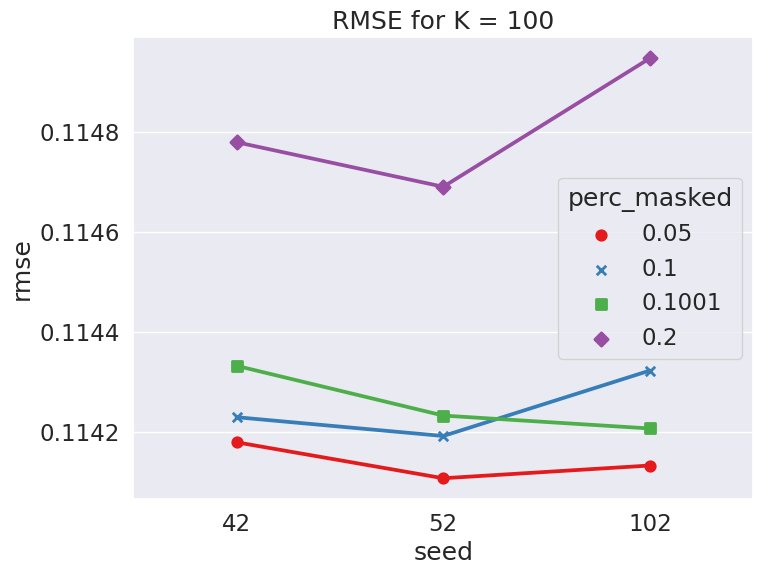

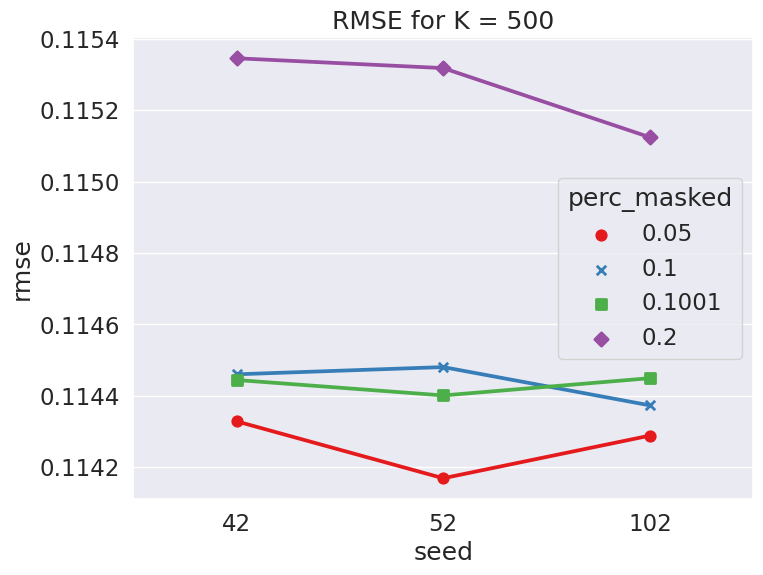

In [49]:
for k in Ks:
    print("K = " + str(k))
    just100 = masked_perf_df[masked_perf_df["K"] == k]
    # make dot plot for just100 xaxis seed, y axis is rmse, each dot shape is differed based on perc_masked
    sns.set_style("whitegrid")
    sns.set_context("paper")
    sns.set(font_scale=1.5)
    plt.figure(figsize=(8, 6))
    sns.pointplot(x="seed", y="rmse", data=just100, palette="Set1", hue="perc_masked", markers=["o", "x", "s", "D"])
    # add title for plot to be which K is shown
    plt.title("RMSE for K = " + str(k))

### Run full model

In [50]:
full_total_counts_tensor

tensor(indices=tensor([[    0,     0,     0,  ...,  2005,  2005,  2005],
                       [    0,     1, 16117,  ..., 18765, 18856, 18857]]),
       values=tensor([25., 25., 25.,  ...,  1.,  1.,  1.]),
       size=(2405, 19164), nnz=9594318, layout=torch.sparse_coo)

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB
Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a Beta-binomial distribution with concentration parameter 50.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 5762
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 86977781.2561767
Epoch 35, Elbo loss: 72042430.11112402
Epoch 70, Elbo loss: 59972405.22225666
Epoch 105, Elbo loss: 49135922.1798354
Epoch 140, Elbo loss: 39542889.423034005
Epoch 175, Elbo loss: 31966953.142781753
Epoch 210, Elbo loss: 26668880.6337476
Epoch 245, Elbo loss: 23344551.208156
Epoch 280, Elbo loss: 21446080.195467155
Epoch 315, Elbo loss: 20349835.871591344
Epoch 350, Elbo loss: 19715200.833838142
Epoch 385, 

Elbo loss: 18048053.464592256


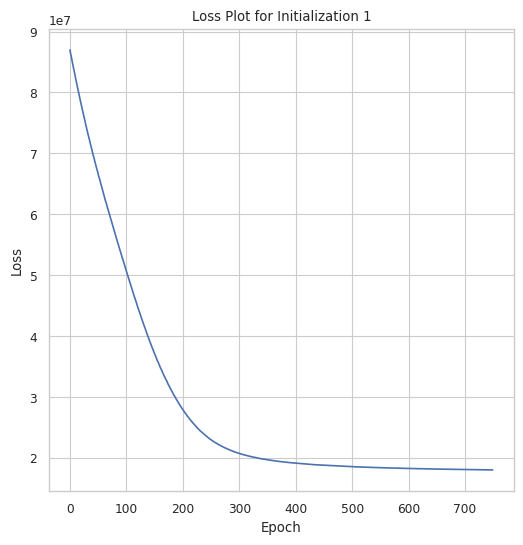

Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------


In [94]:
reload(factor_model)
best_K = 100
K = best_K
input_conc = 50
# set input_conc to inf
#input_conc = float('inf')
all_results = factor_model.main(full_y_tensor, full_total_counts_tensor, num_initializations=1, use_global_prior=True, input_conc=input_conc, K=K, lr=0.01, loss_plot=True, num_epochs=750, save_to_file = False)

In [83]:
# extract latent variables for all iterations 
latent_results = {} 
for i in range(len(all_results)):
    latent_vars = all_results[i]['latent_vars']
    pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
    conc = latent_vars["dir_conc"] # one scaling value 
    assign_post = latent_vars["assign"]
    psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster
    a = latent_vars["a"] 
    b = latent_vars["b"] 
    print("The inferred concentration parameter is: " + str(conc))
    print("The inferred pi parameter is: " + str(pi))
    # add all latent variables to latent_results dictionary
    latent_results[i] = {"pi": pi, "conc": conc, "assign_post": assign_post, "psis": psis, "a": a, "b": b}

The inferred concentration parameter is: 21.849487
The inferred pi parameter is: [0.0967705  0.00901554 0.00885218 0.00917046 0.02145518 0.01572066
 0.00904449 0.02569349 0.00866802 0.0123653  0.01205517 0.01195376
 0.01760801 0.00816516 0.00864282 0.01089289 0.00866053 0.01987541
 0.00846775 0.00785467 0.00839554 0.00855251 0.00829761 0.00858175
 0.00781978 0.01881377 0.00782219 0.00929549 0.01521145 0.0141696
 0.00899837 0.01133153 0.01838171 0.01119974 0.00804378 0.01097554
 0.00777531 0.00780573 0.01194409 0.00817146 0.01150115 0.00817348
 0.01084918 0.01190008 0.00781503 0.0082322  0.00788566 0.01027297
 0.01214429 0.01036775 0.00772998 0.01113775 0.00799508 0.00989881
 0.00850545 0.01005077 0.00801579 0.00775414 0.00777746 0.00757721
 0.00689014 0.00853807 0.00824139 0.00938164 0.00720542 0.0071679
 0.00760082 0.00702279 0.00991377 0.00686062 0.00807744 0.00702507
 0.00853497 0.00673402 0.00695574 0.00831172 0.00743296 0.00700546
 0.00714872 0.00775765 0.00766851 0.00710129 0.006

In [84]:
cell_types_id = sim_data[["cell_id", "cell_id_index", "new_cell_type"]].drop_duplicates()
# reorder by cell_id_index
cell_types_id = cell_types_id.sort_values(by = ["cell_id_index"])
cell_types_id.head()

,cell_id,cell_id_index,new_cell_type
0,A1-B000167-3_56_F-1-1_Mammary_Gland_basal_cell,0,0
6429,A10-B000166-3_56_F-1-1_Mammary_Gland_basal_cell,1,0
1677,A10-B002433-3_38_F-1-1_Mammary_Gland_basal_cell,2,0
1473,A10-B002435-3_39_F-1-1_Mammary_Gland_basal_cell,3,0
6420,A10-B002436-3_39_F-1-1_Mammary_Gland_basal_cell,4,0


In [85]:
cell_types_id.new_cell_type.value_counts()

0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64

In [86]:
# from dictionary of latent variables, get the assign_post for each iteration and add to a dataframe
assign_post = []
for i in range(len(latent_results)):
    assign_post_df = pd.DataFrame(latent_results[i]["assign_post"])
    assign_post_df["new_cell_type"] = cell_types_id.new_cell_type.values
    print(assign_post_df.new_cell_type.value_counts())
    assign_post.append(latent_results[i]["assign_post"])

0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64


### Evaluate latent factor space

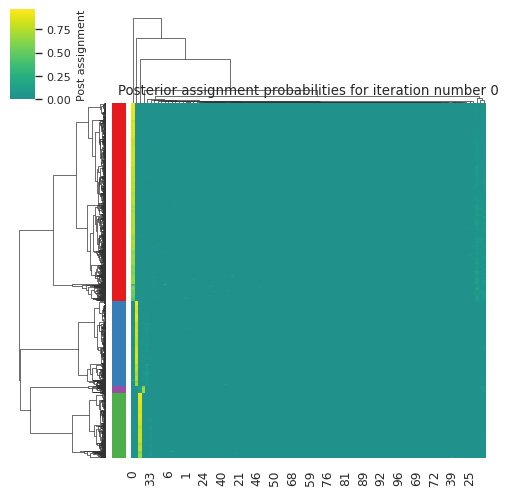

In [87]:
import seaborn as sns

color_palette = sns.color_palette("Set1", n_colors=len(cell_types_id['new_cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_id['new_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_types_id.new_cell_type.values

# create colours for each cell type 
cell_type_colors = {new_cell_type: color for new_cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[new_cell_type] for new_cell_type in cell_types]

for i in range(len(assign_post)):
    cluster = sns.clustermap(
        data=assign_post[i],
        method='complete',
        cmap="viridis",
        annot=False,
        fmt=".2f",
        yticklabels=False,
        figsize=(5, 5),
        center=0,
        row_colors=row_colors,  # Apply row colors
        cbar_kws={'label': 'Post assignment'} 
        )
    cluster.cax.set_ylabel('Post assignment', size=8)
    # add title 
    cluster.ax_heatmap.set_title('Posterior assignment probabilities for iteration number ' + str(i))
    # Increase font size for color bar tick labels:
    cbar_ax = cluster.cax
    for label in cbar_ax.yaxis.get_ticklabels():
        label.set_size(8)

In [88]:
umaps = []

for i in range(len(assign_post)):
    print("Running UMAP for iteration number " + str(i))
    # make UMAP using average assign_post across seeds and color points by cell_type 
    reducer = umap.UMAP(n_components=10, random_state=42)
    embedding = reducer.fit_transform(assign_post[i])
    umaps.append(embedding)

Running UMAP for iteration number 0


In [78]:
# make function for plotting UMAPs 
def umap_plot(umap, cell_type_colors, cell_types):
    sns.set_style("whitegrid")
    sns.set_context("paper")
    plt.figure(figsize=(4, 4))    
    plt.scatter(umap[:, 0], umap[:, 1],
        c=[cell_type_colors[cell_type] for cell_type in cell_types],
        s=8, alpha=0.4)
    # xlab 
    plt.xlabel("UMAP 1")
    # ylab
    plt.ylabel("UMAP 2")

Plotting UMAP for iteration number 0


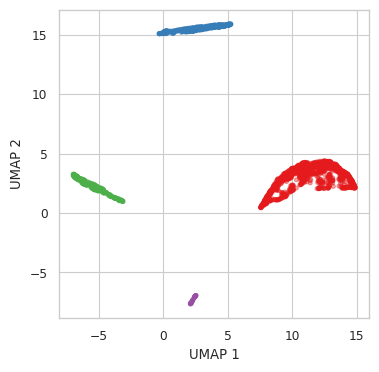

In [61]:
for i in range(len(umaps)):
    print("Plotting UMAP for iteration number " + str(i))
    umap_plot(umaps[i], cell_type_colors, cell_types)

Text(0, 0.5, 'Number of cells')

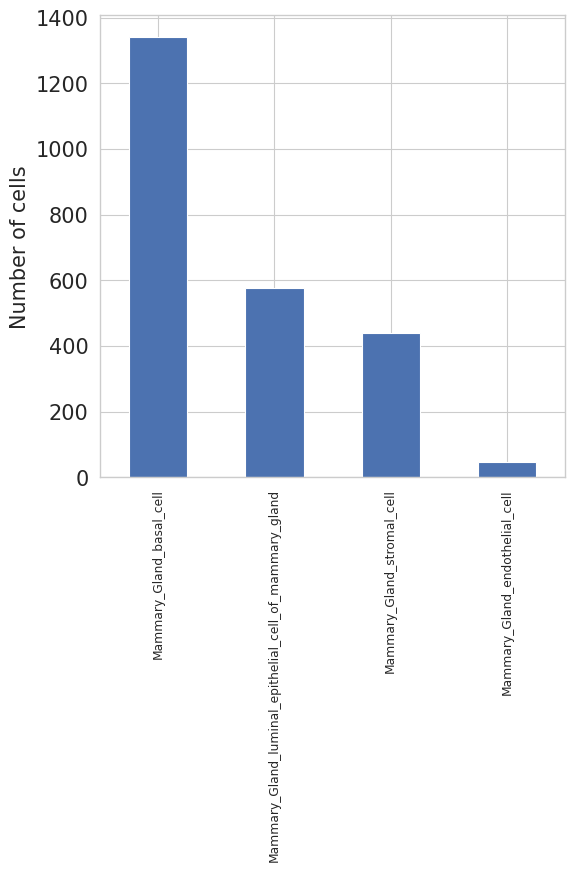

In [62]:
# make a histogram of number of cells in each cell type in cell_ids_conversion
cell_ids_conversion.cell_type.value_counts().plot(kind='bar') 

# increase font of y-axis labels and ticks 
plt.yticks(fontsize=15)
plt.ylabel("Number of cells", fontsize=15)

          pi    factor iteration
0   0.096771   Factor0         0
7   0.025693   Factor7         0
4   0.021455   Factor4         0
17  0.019875  Factor17         0
25  0.018814  Factor25         0
32  0.018382  Factor32         0
12  0.017608  Factor12         0
5   0.015721   Factor5         0
28  0.015211  Factor28         0
29  0.014170  Factor29         0
9   0.012365   Factor9         0
48  0.012144  Factor48         0
10  0.012055  Factor10         0
11  0.011954  Factor11         0
38  0.011944  Factor38         0
43  0.011900  Factor43         0
40  0.011501  Factor40         0
31  0.011332  Factor31         0
33  0.011200  Factor33         0
51  0.011138  Factor51         0
35  0.010976  Factor35         0
15  0.010893  Factor15         0
42  0.010849  Factor42         0
49  0.010368  Factor49         0
47  0.010273  Factor47         0
55  0.010051  Factor55         0


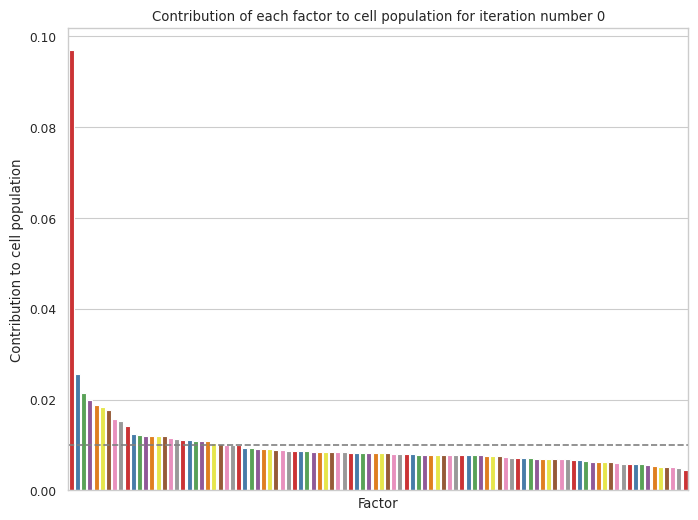

In [89]:
# loop through all restults and make barplot of contribute of each factor to cell population pi

for i in range(len(latent_results)):
    pi = latent_results[i]["pi"]
    pi_df = pd.DataFrame(pi, columns = ["pi"])
    pi_df["factor"] = "Factor" + pi_df.index.astype(str)
    pi_df["iteration"] = i
    pi_df["iteration"] = pi_df["iteration"].astype(str)
    pi_df["factor"] = pi_df["factor"].astype(str)
    pi_df["pi"] = pi_df["pi"].astype(float)
    # order by pi
    pi_df = pi_df.sort_values(by = ["pi"], ascending = False)
    # prnt the factors with contribution greater than 0.01
    print(pi_df[pi_df["pi"] > 0.01])    
    # make barplot
    sns.set_style("whitegrid")
    sns.set_context("paper")
    plt.figure(figsize=(8, 6))
    ax = sns.barplot(x="factor", y="pi", data=pi_df, palette="Set1")
    # draw a line at 0.01 
    ax.axhline(0.01, color='grey', linestyle='--')
    ax.set_xlabel("Factor")
    # remove xaxis ticks 
    ax.set_xticks([])
    ax.set_ylabel("Contribution to cell population")
    ax.set_title("Contribution of each factor to cell population for iteration number " + str(i))
    plt.show()

In [92]:
print("When concentration is lower, contribution to cell population is higher for a smaller number of factors")

When concentration is lower, contribution to cell population is higher for a smaller number of factors


In [80]:
# average junction behaviour of 0.4 means that given 100 reads, this junction will likely get 40 reads

can make simulation more hierarchical first sample psi_o ~ beta(0.5, 0.5) and psi_c for each cell type 

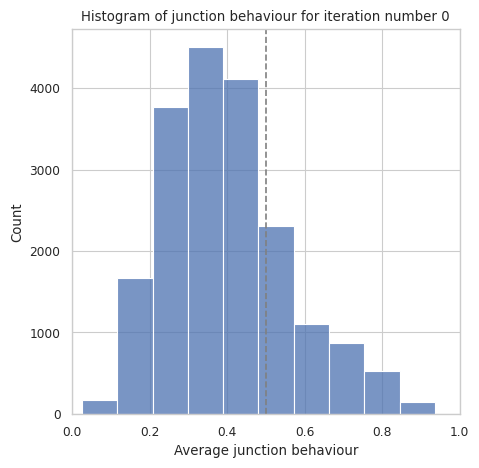

In [66]:
# get average junction behaviour 
for i in range(len(latent_results)):
    junc_beh = latent_results[i]["a"] / (latent_results[i]["a"] + latent_results[i]["b"])
    junc_beh_df = pd.DataFrame(junc_beh, columns = ["junction_beh"])
    junc_beh_df["junction_id_index"] = junc_beh_df.index
    junc_beh_df["iteration"] = i
    # make a histogram of junction behaviour
    sns.set_style("whitegrid")
    sns.set_context("paper")
    plt.figure(figsize=(5, 5))
    sns.histplot(junc_beh_df.junction_beh, bins=10)
    # make xaxis 0 to 1 
    plt.xlim(0, 1)
    plt.xlabel("Average junction behaviour")
    # draw a line a 0.5 
    plt.axvline(0.5, color='grey', linestyle='--')
    plt.title("Histogram of junction behaviour for iteration number " + str(i))
    plt.show()

In [67]:
# now let's look at psis 
psis = latent_results[0]["psis"]
psis.shape # K by J 

# rotate so it's J by K
psis = psis.T

# now convert to dataframe
psis_df = pd.DataFrame(psis)
psis_df["junction_id_index"] = psis_df.index

# calculate junction standard deviation across the K factors 
psis_df["std"] = psis_df[psis_df.columns[0:K]].std(axis=1)

# sort by std
psis_df = psis_df.sort_values(by = ["std"], ascending = False)
psis_df.head()

,0,1,2,3,4,5,6,7,8,9,...,92,93,94,95,96,97,98,99,junction_id_index,std
18589,0.003677,0.625848,0.015931,0.465265,0.054119,0.959448,0.876497,0.061996,0.996381,0.893055,...,0.278805,0.139795,0.375194,0.908756,0.885792,0.615641,0.459002,0.380147,18589,0.368553
13483,0.004826,0.853324,0.065897,0.106837,0.019355,0.661551,0.943191,0.079306,0.998112,0.625986,...,0.196352,0.117156,0.490420,0.270953,0.243212,0.627686,0.331525,0.966365,13483,0.363631
17685,0.966134,0.398467,0.951045,0.219711,0.950742,0.101254,0.746230,0.939742,0.072303,0.153698,...,0.209742,0.761770,0.518088,0.875175,0.041583,0.844031,0.063649,0.880506,17685,0.361434
16485,0.612382,0.670704,0.926279,0.986247,0.900648,0.602346,0.938844,0.224560,0.020975,0.921472,...,0.035865,0.059261,0.766394,0.275945,0.940575,0.661798,0.904987,0.216320,16485,0.358542
12348,0.995852,0.827085,0.976001,0.993903,0.960820,0.704159,0.152018,0.890635,0.001774,0.495064,...,0.577886,0.394210,0.103812,0.203366,0.060262,0.430150,0.936005,0.336748,12348,0.353247


<Figure size 800x600 with 0 Axes>

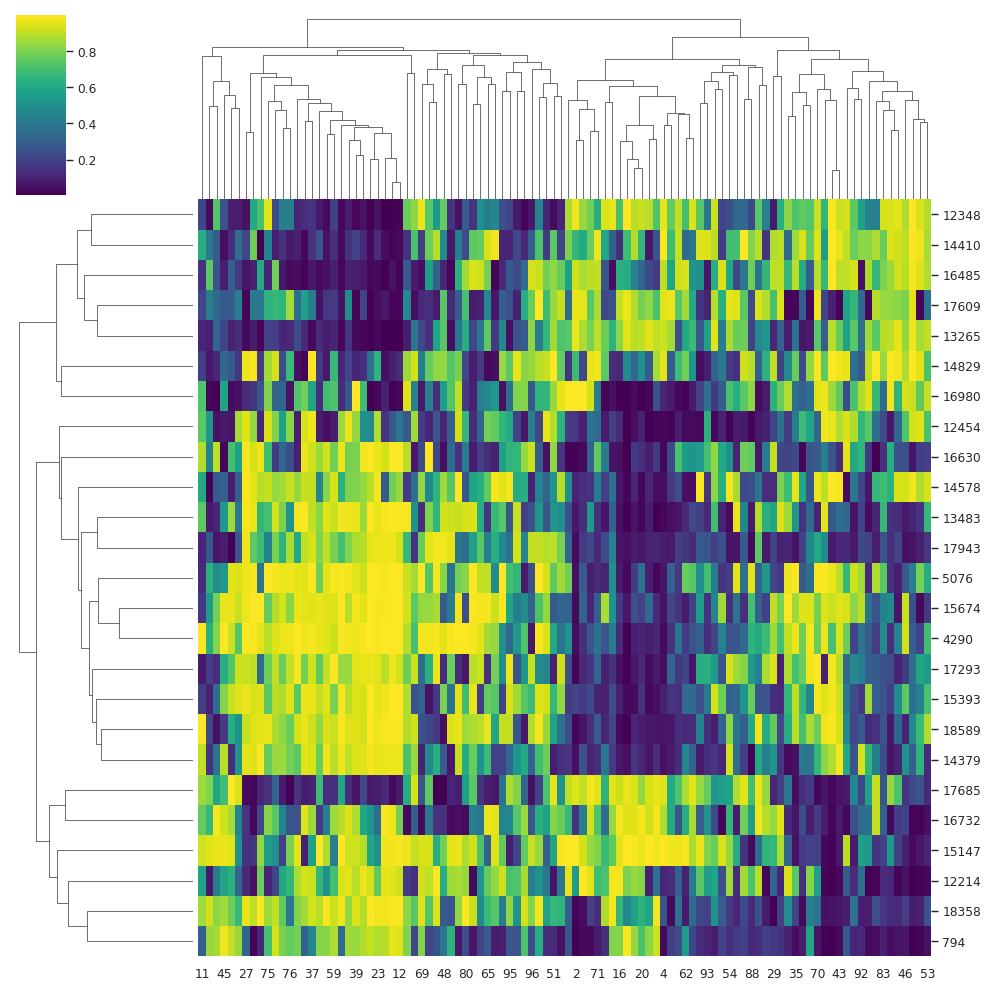

In [68]:
# make a heatmap of psis for the top 5 junctions across factors
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(8, 6))
ax = sns.clustermap(psis_df[psis_df.columns[0:K]].iloc[0:25], cmap="viridis")

In [69]:
reload(factor_model)

2.1.0.dev20230321+cu117
11.7
Tesla V100-PCIE-16GB


<module 'factor_model' from '/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/factor_model.py'>

In [95]:
# evaluate overall likelihood of the model given observed data
res = latent_results[0]
pred = torch.mm(torch.tensor(res["assign_post"]), torch.tensor(res["psis"]))
input_conc = factor_model.convertr(input_conc, "bb_conc")
print(input_conc)
# make sure everything is on cpu going into my_log_prob
pred = pred.cpu()
input_conc = input_conc.cpu()
binom_loglik = factor_model.my_log_prob(full_y_tensor.cpu(), full_total_counts_tensor.cpu(), pred, input_conc)
print("The binomial log likelihood is: " + str(binom_loglik))

tensor(50.)
The binomial log likelihood is: tensor(-25973144., device='cpu')


K set to 100
- When input_conc is 0.5, bbinomial log lik = -29761240
- When input_conc is 1, bbinomial log lik = -26627368
- When input conc is 2, bbinomial log lik = -24241776
- When input conc is 50, bbinomial log lik = -25973144
- When input conc is inf, bbinomial log lik = -16072950

Text(0, 0.5, 'Negative log likelihood')

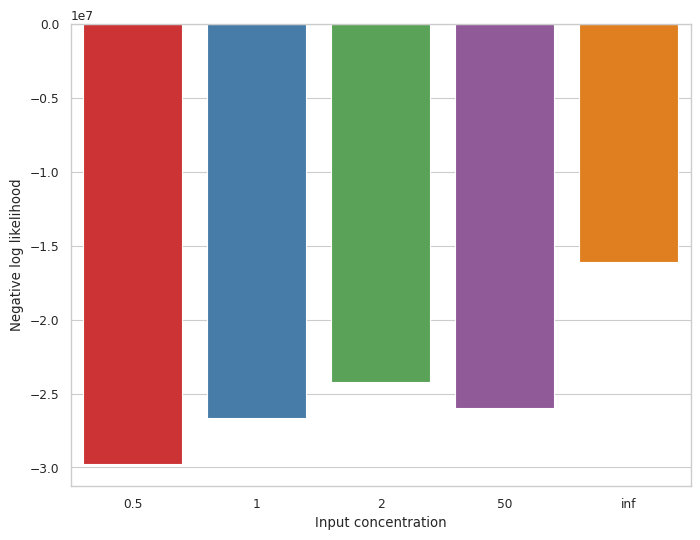

In [96]:
# make a barplot of these values -29882312 -26755432 -24128212 -17080404 -15896266 where xaxis is input_conc, 0.5,1,2,50,inf
data_vals = [-29761240, -26627368, -24241776, -25973144, -16072950]
axislabs = ["0.5", "1", "2", "50", "inf"]
sns.set_style("whitegrid")
sns.set_context("paper")
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=axislabs, y=data_vals, palette="Set1")
ax.set_xlabel("Input concentration")
# y axis is negative log likelihood
ax.set_ylabel("Negative log likelihood")

### Take model with K=100 and prune the very lowly used factors. Re-calculate performance metrics (1) without re-normalizing pi vector and (2) with normalizing pi vector

In [98]:
# extract latent variables for all iterations 
latent_results = {} 
for i in range(len(all_results)):
    latent_vars = all_results[i]['latent_vars']
    pi = latent_vars["pi"] # overall contribution of each factor to cell population, one value per k
    conc = latent_vars["dir_conc"] # one scaling value 
    assign_post = latent_vars["assign"]
    psis = latent_vars["psi"] # psi is the probability of a junction being used in a cluster
    a = latent_vars["a"] 
    b = latent_vars["b"] 
    print("The inferred concentration parameter is: " + str(conc))
    print("The inferred pi parameter is: " + str(pi))
    # add all latent variables to latent_results dictionary
    latent_results[i] = {"pi": pi, "conc": conc, "assign_post": assign_post, "psis": psis, "a": a, "b": b}

The inferred concentration parameter is: 13.691226
The inferred pi parameter is: [0.06656208 0.06708974 0.0124872  0.01100438 0.0272631  0.01058715
 0.01461838 0.01062645 0.03376006 0.01875487 0.01084443 0.01098362
 0.01433991 0.0091596  0.00897343 0.00935281 0.01591015 0.01210159
 0.01119893 0.01436016 0.00870134 0.00892274 0.00881052 0.01524933
 0.01237012 0.01194483 0.01418751 0.00793083 0.00799822 0.00795628
 0.01076282 0.01240551 0.00842412 0.00828955 0.00781338 0.01407732
 0.00880311 0.00905506 0.00798013 0.01251268 0.00719377 0.00996106
 0.00815157 0.01005119 0.0095806  0.00849148 0.0097196  0.00883635
 0.00701428 0.00758762 0.00705097 0.00804573 0.00714689 0.00815344
 0.00892738 0.00677242 0.00981128 0.00671353 0.00718878 0.00850031
 0.00807258 0.00658546 0.00828377 0.00649643 0.00792237 0.006843
 0.00772033 0.00692523 0.00636643 0.00671106 0.00610355 0.00621762
 0.00771268 0.00646672 0.00609028 0.00655599 0.00637172 0.00649504
 0.00584616 0.00591921 0.00664984 0.00568676 0.006

In [99]:
# iterate through all results and evaluate pi from latent variables, remove pi values that are less than 0.01

pruned_latent_results = []

for i in range(len(latent_results)):
    pi = latent_results[i]["pi"]
    
    # identify factors with pi less than 0.01
    pi_less_001 = np.where(pi < 0.01)
    
    # remove these factors from pi
    pi = np.delete(pi, pi_less_001)

    # remove these factors from psis
    psis = latent_results[i]["psis"]
    psis = np.delete(psis, pi_less_001, axis=0)

    # remove these factors from assign_post
    assign_post = latent_results[i]["assign_post"]
    assign_post = np.delete(assign_post, pi_less_001, axis=1)
    
    # also save a, b and conc 
    a = latent_results[i]["a"]
    b = latent_results[i]["b"]
    conc = latent_results[i]["conc"]

    print("The final number of factors is: " + str(len(pi)))
    # add to pruned_latent_results
    pruned_latent_results.append({"pi": pi, "conc": conc, "assign_post": assign_post, "psis": psis, "a": a, "b": b})

The final number of factors is: 26


In [100]:
# from dictionary of latent variables, get the assign_post for each iteration and add to a dataframe
assign_post = []
for i in range(len(pruned_latent_results)):
    assign_post_df = pd.DataFrame(pruned_latent_results[i]["assign_post"])
    assign_post_df["new_cell_type"] = cell_types_id.new_cell_type.values
    print(assign_post_df.new_cell_type.value_counts())
    assign_post.append(pruned_latent_results[i]["assign_post"])

0    1340
2     578
3     440
1      47
Name: new_cell_type, dtype: int64


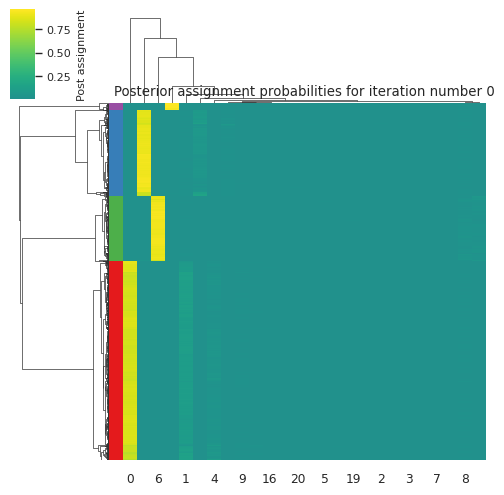

In [102]:
color_palette = sns.color_palette("Set1", n_colors=len(cell_types_id['new_cell_type'].unique()))
# Create a color bar legend
legend = sns.color_palette(palette=color_palette, as_cmap=True)

# Obtain cell type labels for every cell in the matrix also 
unique_cell_types = cell_types_id['new_cell_type'].unique()
num_unique_types = len(unique_cell_types)
colors = sns.color_palette('Set1', n_colors=num_unique_types)  # You can use any color palette
cell_types = cell_types_id.new_cell_type.values

# create colours for each cell type 
cell_type_colors = {new_cell_type: color for new_cell_type, color in zip(unique_cell_types, colors)}
row_colors = [cell_type_colors[new_cell_type] for new_cell_type in cell_types]

for i in range(len(assign_post)):
    cluster = sns.clustermap(
        data=assign_post[i],
        method='complete',
        cmap="viridis",
        annot=False,
        fmt=".2f",
        yticklabels=False,
        figsize=(5, 5),
        center=0,
        row_colors=row_colors,  # Apply row colors
        cbar_kws={'label': 'Post assignment'} 
        )
    cluster.cax.set_ylabel('Post assignment', size=8)
    # add title 
    cluster.ax_heatmap.set_title('Posterior assignment probabilities for iteration number ' + str(i))
    # Increase font size for color bar tick labels:
    cbar_ax = cluster.cax
    for label in cbar_ax.yaxis.get_ticklabels():
        label.set_size(8)

In [104]:
print(Ks)
print(seeds_used)
print(seeds)

[5, 20, 100, 500]
[810362, 306774, 347454, 883948]
[42, 52, 102]


In [105]:
# evaluate pruned models on masking tasks 
# Now can run factor model on masked data
all_Ks_results = {}
masked_perf_w_pruning = []

# set input_conc to inf 
input_conc = float('inf') 

for k in Ks:
    
    print("------------------------------------------------")
    print("Running factor model for K = " + str(k))
    print("------------------------------------------------")
    
    # now also iterate over masking percentages 
    for i in range(len(masking_percs)):
        
        print("The masking percentage is: " + str(masking_percs[i]))
        y_tensor, total_counts_tensor = model_input_files[i]
        # run factor model
        masked_results = factor_model.main(y_tensor, total_counts_tensor, num_initializations=3, use_global_prior=True, input_conc=input_conc, K=k, seeds=seeds,loss_plot=False, num_epochs=100, lr = 0.01, save_to_file = False)
        # prune the results based on pi to only keep factors with pi > 0.01 and evaluate the model 

        for res in masked_results:
            # get seed that was used 
            seed = res['seed']

            # get latent variables
            psi = res['latent_vars']["psi"] # psi is the probability of a junction being used in a cluster
            assign_post=res['latent_vars']["assign"]
            pi = res['latent_vars']["pi"]

            # get max usage across cells for each factor via assign_post
            max_usage = np.max(assign_post, axis=0)
            print("The max usage across cells for each factor is: " + str(max_usage))

            # let's prune the results based on max_usage to only keep factors with max_usage > 0.01
            max_usage_less_001 = np.where(max_usage < 0.01)
            print(psi.shape)
            psi = np.delete(psi, max_usage_less_001, axis=0)
            print(psi.shape)
            print(assign_post.shape)
            assign_post = np.delete(assign_post, max_usage_less_001, axis=1)
            print(assign_post.shape)
            
            pi = np.delete(pi, max_usage_less_001)
            
            print("The number of factors after pruning is: " + str(len(pi)))
            new_K = len(pi)

            # if new_K is empty of nan replace with 0
            if np.isnan(new_K):
                new_K = 0
            
            old_k = k 

            # get K 
            K = psi.shape[0]
            J = psi.shape[1]

            # get scores 
            mask_matrix_used = masks_list[i]
            l1, r, l2, rmse = evaluate_model(junc_counts.toarray(), cluster_counts.toarray(), psi, assign_post, mask_matrix_used)

            # get num epochs trained for 
            nepoch = len(res["losses"])

            # save to list 
            masked_perf.append([seed, l1, r, l2, rmse, old_k, new_K, masking_percs[i], J, nepoch])

------------------------------------------------
Running factor model for K = 5
------------------------------------------------
The masking percentage is: 0.05
Using prior for a and b per junction to model average behaviour!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Using a Beta-binomial distribution with concentration parameter 1.
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 1 with seed 42
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 30643549.922403533
Epoch 35, Elbo loss: 29282143.206849515


Elbo loss: 28345598.368129425


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 52
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 30664857.78100177
Epoch 35, Elbo loss: 29305046.733974673


Elbo loss: 28364338.230514713


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 3 with seed 102
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 30608108.23881614
Epoch 35, Elbo loss: 29255121.166317705


...

Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 2 with seed 52
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 59462854.55305465
Epoch 35, Elbo loss: 52299845.31408772


Elbo loss: 46055838.153365344


Sample from the guide (posterior)
Extract the latent variables
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Initialization 3 with seed 102
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Define the guide using AutoDiagonalNormal based on the model structure.
Fit the model
Epoch 0, Elbo loss: 59598034.38664768
Epoch 35, Elbo loss: 52904625.09805148


Elbo loss: 46517175.42273839


Sample from the guide (posterior)
Extract the latent variables
All initializations complete. Returning results.
------------------------------------------------
The max usage across cells for each factor is: [0.0079947  0.00601675 0.0086845  0.00895163 0.00469757 0.00668476
 0.0078225  0.00611757 0.0067192  0.00788151 0.00447573 0.00510168
 0.0074361  0.00873197 0.00598631 0.00653311 0.00753351 0.00872368
 0.0067047  0.00481994 0.00471667 0.00364595 0.00503273 0.00710138
 0.00920811 0.00823961 0.00504845 0.00521207 0.00585908 0.00771276
 0.00912979 0.00823668 0.00672639 0.00592526 0.00885823 0.00445528
 0.00480831 0.00818499 0.00613828 0.00775863 0.00462656 0.00645542
 0.00598362 0.00485732 0.00585853 0.00760953 0.00777044 0.00579968
 0.00549537 0.00843142 0.00809801 0.00567603 0.00578735 0.00710075
 0.00784239 0.00543181 0.00459004 0.00432436 0.00555742 0.00859377
 0.00310746 0.00542349 0.00566307 0.00717372 0.00883161 0.0046321
 0.00793238 0.00691842 0.00520673 0.00620179 0.00897517 

In [106]:
masked_perf_df = pd.DataFrame(masked_perf, columns=["seed", "l1", "r", "l2", "rmse", "old_k", "K",  "perc_masked" , "J", "num_epochs"])
masked_perf_df.tail()

,seed,l1,r,l2,rmse,old_k,K,perc_masked,J,num_epochs
91,52,0.333153,NaN,0.202017,0.449463,500,0.0,0.1001,19164,70.0
92,102,0.333153,NaN,0.202017,0.449463,500,0.0,0.1001,19164,70.0
93,42,0.333403,NaN,0.202410,0.449901,500,0.0,0.2000,19164,70.0
94,52,0.333403,NaN,0.202410,0.449901,500,0.0,0.2000,19164,70.0
95,102,0.333403,NaN,0.202410,0.449901,500,0.0,0.2000,19164,70.0


In [107]:
masked_perf_df[masked_perf_df["old_k"] == 100]

,seed,l1,r,l2,rmse,old_k,K,perc_masked,J,num_epochs
24,42,0.066306,0.903442,0.013037,0.114179,100,0.0500,19164.0000,500,NaN
25,52,0.066331,0.903553,0.013020,0.114107,100,0.0500,19164.0000,500,NaN
26,102,0.066448,0.903398,0.013026,0.114132,100,0.0500,19164.0000,500,NaN
27,42,0.066333,0.903344,0.013048,0.114229,100,0.1000,19164.0000,500,NaN
28,52,0.066409,0.903414,0.013040,0.114191,100,0.1000,19164.0000,500,NaN
29,102,0.066576,0.903108,0.013070,0.114322,100,0.1000,19164.0000,500,NaN
30,42,0.066468,0.903112,0.013072,0.114332,100,0.1001,19164.0000,500,NaN
31,52,0.066466,0.903276,0.013049,0.114232,100,0.1001,19164.0000,500,NaN
32,102,0.066508,0.903269,0.013043,0.114206,100,0.1001,19164.0000,500,NaN
33,42,0.066809,0.902351,0.013174,0.114780,100,0.2000,19164.0000,500,NaN


In [ ]:
masked_perf_df.rmse.unique().min()

In [ ]:
# make scatterplot of old_k vs new_K for each masking percentage and colour by rmse 
sns.set_style("whitegrid")
sns.set_context("paper")
sns.set(font_scale=1.5)
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(x="old_k", y="K", data=masked_perf_df, hue="rmse", palette="viridis")
# make rmse color continous 
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), ncol=1)
ax.set_xlabel("Old K")
ax.set_ylabel("New K")
ax.set_title("Old K vs New K for each masking percentage")
plt.show()

In [ ]:
# fit with 100 factors and then prune and get 20 factors, expect to get better metrics than just K=20 factors 
# can also re-normalize the pi vector after prunning 